In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import lightgbm as lgb
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
app_train = pd.read_csv(r'D:\Shinsa AI Automated Loan Approval for Thin-files\data\application_train.csv')
installments = pd.read_csv(r'D:\Shinsa AI Automated Loan Approval for Thin-files\data\installments_payments.csv')
print(f"Kích thước bảng chính: {app_train.shape[0]} dòng, {app_train.shape[1]} cột")
print(f"Kích thước bảng hành vi: {installments.shape[0]} dòng, {installments.shape[1]} cột")

Kích thước bảng chính: 307511 dòng, 122 cột
Kích thước bảng hành vi: 13605401 dòng, 8 cột


In [3]:
print(installments.iloc[0])

SK_ID_PREV                1054186.00
SK_ID_CURR                 161674.00
NUM_INSTALMENT_VERSION          1.00
NUM_INSTALMENT_NUMBER           6.00
DAYS_INSTALMENT             -1180.00
DAYS_ENTRY_PAYMENT          -1187.00
AMT_INSTALMENT               6948.36
AMT_PAYMENT                  6948.36
Name: 0, dtype: float64


In [4]:
# tính số ngày trễ (ngày thực trả - ngày đến hạn)
# âm: trả sớm | dương: trả trễ
installments['DAYS_LATE'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']

# tính số tiền hụt (tiền cam kết đóng - tiền thực đóng)
installments['AMT_SHORTAGE'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']

# groupby theo mã khách hàng
agg_features = installments.groupby('SK_ID_CURR').agg(
    TOTAL_INSTALLMENTS = ('NUM_INSTALMENT_NUMBER', 'count'), # tổng số lần đã thanh toán
    MAX_DAYS_LATE = ('DAYS_LATE', max), # Lần trễ lâu nhất là bao nhiêu ngày?
    MEAN_DAYS_LATE = ('DAYS_LATE', 'mean'), # trung bình hay trễ nhiêu ngày?
    TOTAL_SHORTAGE = ('AMT_SHORTAGE', 'sum') # Có từng quỵt đồng nào chưa?
).reset_index()

df_final = app_train.merge(agg_features, on = 'SK_ID_CURR', how = 'left')
print(f"Kích thước bộ dữ liệu cuối cùng: {df_final.shape[0]} dòng, {df_final.shape[1]} cột.")

Kích thước bộ dữ liệu cuối cùng: 307511 dòng, 126 cột.


## Xử lý DAYS_EMPLOYED

In [5]:
# XỬ LÝ anomaly: DAYS_EMPLOYED = 365243 là mã lỗi cho "thất nghiệp/hưu trí"
df_final['DAYS_EMPLOYED_ANOM'] = (df_final['DAYS_EMPLOYED'] == 365243).astype(int)
# thay giá trị lỗi bằng NaN tránh mô hình học sai
df_final['DAYS_EMPLOYED'] = df_final['DAYS_EMPLOYED'].replace(365243, np.nan)
print(f"Số dòng bị anomaly: {df_final['DAYS_EMPLOYED_ANOM'].sum()}({df_final['DAYS_EMPLOYED_ANOM'].mean()*100:.2f}%)")

Số dòng bị anomaly: 55374(18.01%)


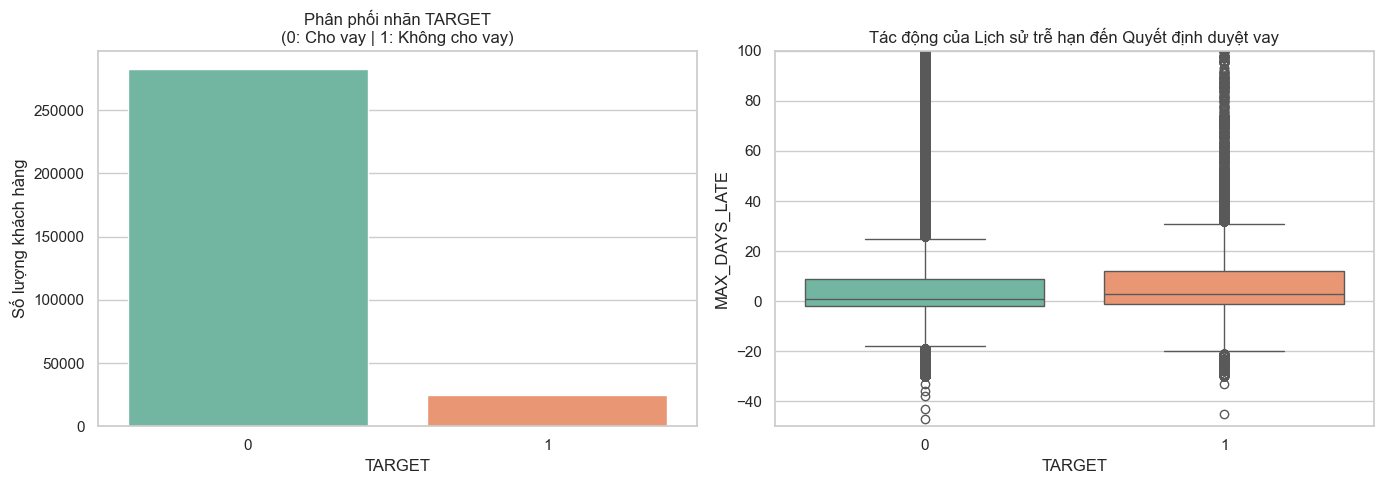

Tỉ lệ dữ liệu bị thiếu (Missing values) ở các cột hành vi:
TOTAL_INSTALLMENTS    5.160141
MAX_DAYS_LATE         5.162742
TOTAL_SHORTAGE        5.160141
dtype: float64


In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Biểu đồ 1: Kiểm tra tính cân bằng của cột Target (Bài toán Yes/No)
sns.countplot(data=df_final, x='TARGET', palette='Set2', ax=axes[0])
axes[0].set_title('Phân phối nhãn TARGET\n(0: Cho vay | 1: Không cho vay)')
axes[0].set_ylabel('Số lượng khách hàng')
# Biểu đồ 2: Quan hệ giữa Số ngày trễ hạn và Việc được duyệt vay
sns.boxplot(data=df_final, x='TARGET', y='MAX_DAYS_LATE', palette='Set2', ax=axes[1])
axes[1].set_title('Tác động của Lịch sử trễ hạn đến Quyết định duyệt vay')
axes[1].set_ylim(-50, 100) # Cắt bớt các giá trị outlier (ngoại lai) quá xa để dễ nhìn
plt.tight_layout()
plt.show()
# Kiểm tra Missing Value của các cột mới tạo
print("Tỉ lệ dữ liệu bị thiếu (Missing values) ở các cột hành vi:")
print((df_final[['TOTAL_INSTALLMENTS', 'MAX_DAYS_LATE', 'TOTAL_SHORTAGE']].isnull().sum() / len(df_final)) * 100)

### 1. Phân tích Dữ liệu khuyết (Missing Values) & Khám phá "Thin-file"

* **Thực trạng:** Các đặc trưng hành vi trích xuất từ bảng `installments_payments` (như `TOTAL_INSTALLMENTS`, `MAX_DAYS_LATE`) ghi nhận tỷ lệ thiếu hụt đồng loạt ở mức **~5.16%**.
* **Nhận xét:** Tập 5.16% này đại diện chính xác cho nhóm đối tượng mục tiêu của bài toán: **Khách hàng "Thin-file"** — những cá nhân chưa từng có lịch sử giao dịch trả góp tại hệ thống trước đây.
* **Xử lý:** Tiến hành impute bằng giá trị `0` để bảo toàn tệp khách hàng tiềm năng, đồng thời buộc hệ thống phải đánh giá rủi ro của họ dựa trên các đặc trưng nhân khẩu học thay vì hành vi trong quá khứ.

### 2. Mức độ Cân bằng của Biến mục tiêu (Target Imbalance)

* **Thực trạng:** Lớp thiểu số (Nhãn `1` - Rủi ro/Không duyệt) chỉ chiếm một tỷ trọng rất nhỏ (khoảng 8%) so với lớp đa số (Nhãn `0` - An toàn).
* **Nhận xét** Việc mất cân bằng sẽ khiến thuật toán bị thiên lệch (bias) về việc dự đoán nhóm an toàn.
* **Xử lý:**

  * Sử dụng tham số `scale_pos_weight` trong thuật toán XGBoost để tối ưu hóa trọng số lớp, phạt nặng mô hình khi dự đoán sai lớp thiểu số.
  * Loại bỏ Accuracy, dùng **ROC-AUC** và **F1-Score / Recall** làm ma trận đánh giá chính.

### 3. Tác động của Đặc trưng Hành vi (Feature Correlation)

* **Thực trạng:** Biểu đồ phân tán (Boxplot) đối chiếu giữa `MAX_DAYS_LATE` (Lịch sử trễ hạn tối đa) và `TARGET` cho thấy ranh giới phân loại rất rõ ràng.
* **Nhận xét:** Nhóm có rủi ro vỡ nợ (cam) có trung vị và độ phân tán của số ngày trễ hạn cao hơn hẳn so với nhóm trả nợ tốt (xanh). 

=> Tính kỷ luật và thói quen thanh toán các khoản nhỏ chính là tín hiệu dự báo rủi ro hiệu quả, hoàn toàn có khả năng thay thế điểm tín dụng truyền thống (CIC/FICO).

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from xgboost import XGBClassifier

In [8]:
# Tiền xử lý và chia tập dữ liệu (baseline model)

# impute
cols_to_fill = ['TOTAL_INSTALLMENTS', 'MAX_DAYS_LATE', 'MEAN_DAYS_LATE', 'TOTAL_SHORTAGE']
for col in cols_to_fill:
    if col in df_final.columns:
        df_final[col] = df_final[col].fillna(0)

# tách biến target và bỏ ID
y = df_final['TARGET']
X = df_final.drop(columns = ['TARGET', 'SK_ID_CURR'])

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [9]:
# chia tập train test (baseline)

# tính tỉ lệ mất cân bằng cho XGBoost
pos_weight = (y == 0).sum() / (y == 1).sum()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Kích thước tập train: {X_train.shape[0]} dòng và {X_train.shape[1]} features (cột)")
print(f"Kích thước tập test: {X_test.shape[0]} dòng.")

Kích thước tập train: 246008 dòng và 233 features (cột)
Kích thước tập test: 61503 dòng.


In [10]:
# Huấn luyện mô hình
print("Model training (baseline) ...!")

model = XGBClassifier(
    scale_pos_weight=pos_weight,
    n_estimators=200,      
    max_depth=5,           
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,             
    tree_method='hist'     
)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model training (baseline) ...!
Model trained successfully!


In [11]:
# Đánh giá mô hình baseline

# dự đoán xác suất
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# đánh giá bằng ROC-AUC
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"Điểm ROC-AUC của mô hình: {auc_score:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Điểm ROC-AUC của mô hình: 0.7638
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.68      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.71      0.77     61503



Đang tính toán giá trị SHAP ...!


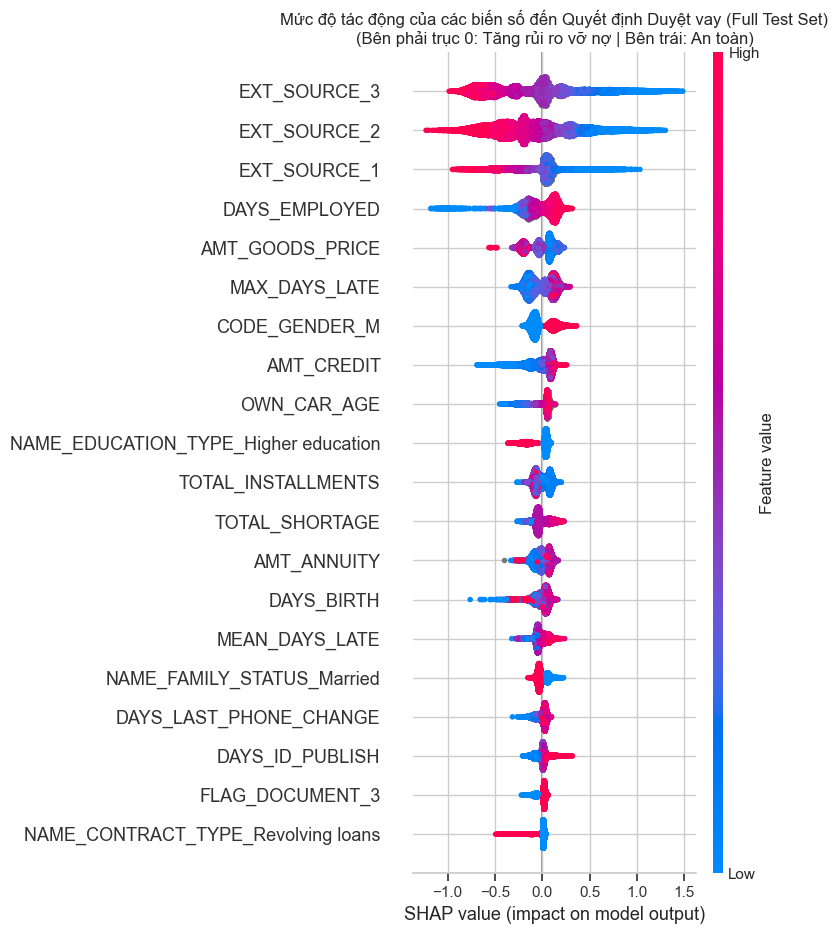

In [12]:
import shap

print("Đang tính toán giá trị SHAP ...!")
# khởi tạo SHAP Explainer
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

# biểu đồ Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.title("Mức độ tác động của các biến số đến Quyết định Duyệt vay (Full Test Set)\n(Bên phải trục 0: Tăng rủi ro vỡ nợ | Bên trái: An toàn)")
plt.tight_layout()
plt.show()

1. **Dữ liệu Ngoại kiểm (External Sources):** Ba biến `EXT_SOURCE` là các điểm số được chuẩn hóa từ các tổ chức bên thứ ba. Quy luật màu sắc thể hiện rất rõ ràng: Các chấm màu xanh (giá trị thấp) kéo dài mạnh về phía bên phải trục 0, báo hiệu rủi ro vỡ nợ tăng vọt. Ngược lại, chấm màu đỏ (giá trị cao) tụ về bên trái, củng cố mức độ an toàn của hồ sơ.

2. **Alternative Data:** Việc `MAX_DAYS_LATE` (Số ngày trễ hạn tối đa) vươn lên top 5 chứng minh cho giả thuyết kinh doanh ban đầu. Những chấm màu đỏ (trễ nhiều ngày) tương quan trực tiếp với việc tăng xác suất vỡ nợ. Điều này xác nhận rằng: Đối với nhóm khách hàng "Thin-file" (thường bị khuyết các điểm `EXT_SOURCE`), mô hình đã chuyển trọng tâm sang đánh giá mức độ kỷ luật trong các khoản thanh toán nhỏ lẻ để ra quyết định.

3. **Hồ sơ Nhân khẩu học:** Ở các thứ hạng tiếp theo, `DAYS_BIRTH` (độ tuổi) chỉ ra rằng khách hàng trẻ tuổi (chấm xanh - vì dữ liệu gốc lưu tuổi ở dạng số âm) có xu hướng rủi ro cao hơn. Điều này hoàn toàn khớp với bài toán cốt lõi nhắm vào đối tượng sinh viên hoặc người trẻ mới đi làm.

## CẢI TIẾN MÔ HÌNH 

In [13]:
# Cải tiến 1: Rút trích đặc trưng chuỗi thời gian
print("Đang tính toán độ dốc (trend) trễ hạn ...!")

# sắp xếp lịch sử thanh toán theo thời gian (DAYS_INSTALMENT tiến về 0 là gần hiện tại nhất)
installments_sorted = installments.sort_values(['SK_ID_CURR', 'DAYS_INSTALMENT'])
# lấy số ngày trễ của lần đóng tiền gần nhất
latest_late = installments_sorted.groupby('SK_ID_CURR').tail(1).set_index('SK_ID_CURR')[['DAYS_LATE']]
latest_late.columns = ['LATEST_DAYS_LATE']
# nối vào df_final và tính trend
# nếu (lần gần nhất) - (trung bình mọi lần) > 0 => khách hàng có xu hướng trễ hẹn nhiều hơn.
df_final = df_final.merge(latest_late, on = 'SK_ID_CURR', how = 'left')
df_final['LATEST_DAYS_LATE'] = df_final['LATEST_DAYS_LATE'].fillna(0)
df_final['LATE_TREND'] = df_final['LATEST_DAYS_LATE'] - df_final['MEAN_DAYS_LATE']

Đang tính toán độ dốc (trend) trễ hạn ...!


In [14]:
# Cải tiến 2: Đổi qua LIGHTGBM
print("Đang chuẩn bị dữ liệu cho LightGBM ...!")

y = df_final['TARGET']
X = df_final.drop(columns=['TARGET', 'SK_ID_CURR'])

# chuyển đổi các cột chữ (object) qua category cho LightGBM
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype('category')

print(f"Số features: {X.shape[1]}, số cột categorical: {len(cat_cols)}")

Đang chuẩn bị dữ liệu cho LightGBM ...!
Số features: 127, số cột categorical: 16


In [15]:
# tách test set
# để đánh giá sự ổn định của model thay vì tin vào 1 số AUC cụ thể thì chạy 5 fold stratified cross_validation trên phần Train+Val gộp lại gọi là temp
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# stratified 5-fold cross validation trên phần temp để đánh giá mức độ ổn định
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc_scores = []
fold_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_temp, y_temp)):
    X_tr, X_val_fold = X_temp.iloc[train_idx], X_temp.iloc[val_idx]
    y_tr, y_val_fold = y_temp.iloc[train_idx], y_temp.iloc[val_idx]
    pos_w = (y_tr == 0).sum() / (y_tr == 1).sum()

    fold_model = lgb.LGBMClassifier(
        scale_pos_weight = pos_w, n_estimators = 300, max_depth = 5,
        learning_rate = 0.05, random_state = 42, n_jobs = -1, verbose = -1
    )
    fold_model.fit(X_tr, y_tr, categorical_feature = cat_cols)

    fold_pred = fold_model.predict_proba(X_val_fold)[:, 1]
    fold_auc = roc_auc_score(y_val_fold, fold_pred)
    cv_auc_scores.append(fold_auc)
    fold_importances.append(fold_model.feature_importances_)
    print(f"Fold {fold+1}: AUC = {fold_auc:.4f}")

print(f"CV AUC trung bình: {np.mean(cv_auc_scores):4f} (+/-{np.std(cv_auc_scores):4f})")
print("Độ lệch chuẩn mà nhỏ ==> model ổn định qua các fold!")

Fold 1: AUC = 0.7613
Fold 2: AUC = 0.7537
Fold 3: AUC = 0.7660
Fold 4: AUC = 0.7564
Fold 5: AUC = 0.7658
CV AUC trung bình: 0.760607 (+/-0.004938)
Độ lệch chuẩn mà nhỏ ==> model ổn định qua các fold!


In [16]:
# Kiểm tra độ ổn định của Feature Importance qua các fold
# một feature quan trọng nhưng ko ổn định (std cao so với mean qua các fold) là dấu hiệu overfitting theo nhiễu của từng fold cụ thể

imp_df = pd.DataFrame(fold_importances, columns = X_temp.columns)
imp_sumary = pd.DataFrame({
    'mean_importance': imp_df.mean(),
    'std_importance': imp_df.std()
}).sort_values('mean_importance', ascending = False)

imp_sumary['cv_ratio'] = imp_sumary['std_importance'] / (imp_sumary['mean_importance'] + 1e-9)

print("Top 15 features quan trọng nhất (trung bình qua 5 folds:)")
print(imp_sumary.head(15))
print("Features có độ biến động cao nhất (cv_ratio lớn --> kém ổn định)")
print()
print(imp_sumary.sort_values('cv_ratio', ascending = False).head(10))

Top 15 features quan trọng nhất (trung bình qua 5 folds:)
                        mean_importance  std_importance  cv_ratio
ORGANIZATION_TYPE                1344.2       17.210462  0.012803
EXT_SOURCE_3                      590.4       24.378269  0.041291
EXT_SOURCE_2                      432.8       22.129166  0.051130
EXT_SOURCE_1                      400.4       11.781341  0.029424
AMT_CREDIT                        329.0        8.366600  0.025430
DAYS_BIRTH                        285.6       23.901883  0.083690
DAYS_EMPLOYED                     263.0       25.288337  0.096153
OCCUPATION_TYPE                   254.6       15.789237  0.062016
AMT_ANNUITY                       249.8       12.557866  0.050272
AMT_GOODS_PRICE                   240.4       29.099828  0.121048
TOTAL_INSTALLMENTS                234.2       15.833509  0.067607
DAYS_LAST_PHONE_CHANGE            207.2       16.300307  0.078669
DAYS_ID_PUBLISH                   202.8       11.344602  0.055940
MAX_DAYS_LATE     

### Hyperparameter tuning (optuna)
Thay vì chọn n_estimators, max_depth, learning_rate thủ công thì dùng optuna để tìm bộ tham số tối ưu AUC trung bình qua cross_validation.

In [17]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    scores = []
    for train_idx, val_idx in skf.split(X_temp, y_temp):
        X_tr, X_v = X_temp.iloc[train_idx], X_temp.iloc[val_idx]
        y_tr, y_v = y_temp.iloc[train_idx], y_temp.iloc[val_idx]
        pos_w = (y_tr == 0).sum() / (y_tr == 1).sum()
        m = lgb.LGBMClassifier(scale_pos_weight=pos_w, **params)
        m.fit(X_tr, y_tr, categorical_feature=cat_cols)
        scores.append(roc_auc_score(y_v, m.predict_proba(X_v)[:, 1]))
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best CV AUC:", study.best_value)
print("Best params:", study.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

Best CV AUC: 0.762630452895861
Best params: {'n_estimators': 339, 'max_depth': 3, 'learning_rate': 0.09397142672653448, 'num_leaves': 20, 'min_child_samples': 81}


In [18]:
# tách riêng train/val từ temp (val dùng để chọn threshold)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

best_params = study.best_params
lgbm_model = lgb.LGBMClassifier(
    scale_pos_weight=pos_weight, random_state=42, n_jobs=-1, verbose=-1, **best_params
)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_cols)

y_val_prob = lgbm_model.predict_proba(X_val)[:, 1]
print(f"AUC trên Validation: {roc_auc_score(y_val, y_val_prob):.4f}")

AUC trên Validation: 0.7669


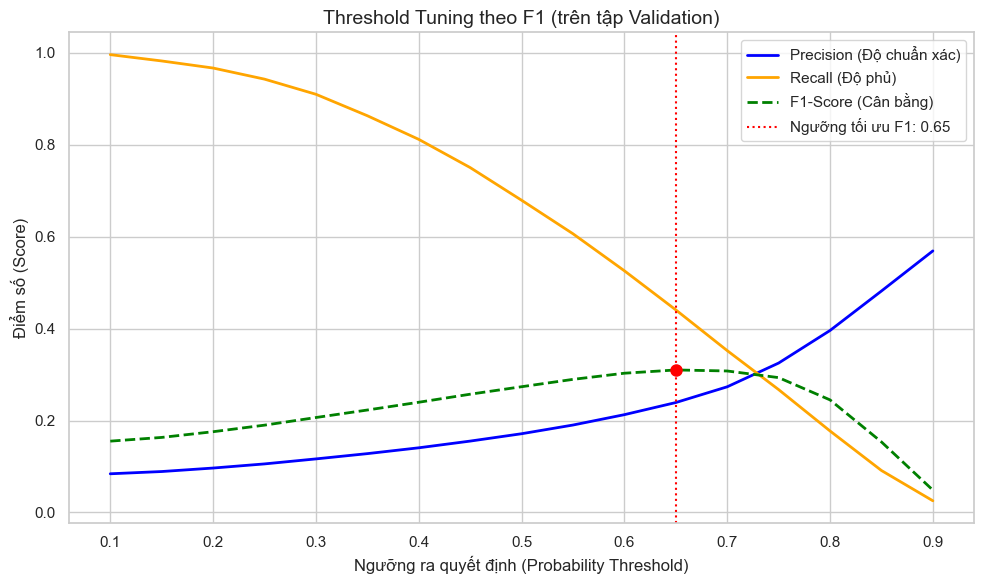

Ngưỡng tối ưu theo F1 (chọn trên Validation): 0.65
F1-Score cực đại: 0.3101 | Precision: 0.2391 | Recall: 0.4408


In [19]:
# Cải tiến 3a: THRESHOLD TUNING theo F1-Score (chọn trên VALIDATION, không phải Test)
thresholds = np.arange(0.1, 0.95, 0.05)
f1_scores, precisions, recalls = [], [], []

for thresh in thresholds:
    y_pred_custom = (y_val_prob >= thresh).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_custom))
    precisions.append(precision_score(y_val, y_pred_custom))
    recalls.append(recall_score(y_val, y_pred_custom))

best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision (Độ chuẩn xác)', color='blue', linewidth=2)
plt.plot(thresholds, recalls, label='Recall (Độ phủ)', color='orange', linewidth=2)
plt.plot(thresholds, f1_scores, label='F1-Score (Cân bằng)', color='green', linestyle='--', linewidth=2)
plt.axvline(x=best_thresh, color='red', linestyle=':', label=f'Ngưỡng tối ưu F1: {best_thresh:.2f}')
plt.plot(best_thresh, f1_scores[best_idx], marker='o', markersize=8, color='red')
plt.title('Threshold Tuning theo F1 (trên tập Validation)', fontsize=14)
plt.xlabel('Ngưỡng ra quyết định (Probability Threshold)', fontsize=12)
plt.ylabel('Điểm số (Score)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Ngưỡng tối ưu theo F1 (chọn trên Validation): {best_thresh:.2f}")
print(f"F1-Score cực đại: {f1_scores[best_idx]:.4f} | Precision: {precisions[best_idx]:.4f} | Recall: {recalls[best_idx]:.4f}")

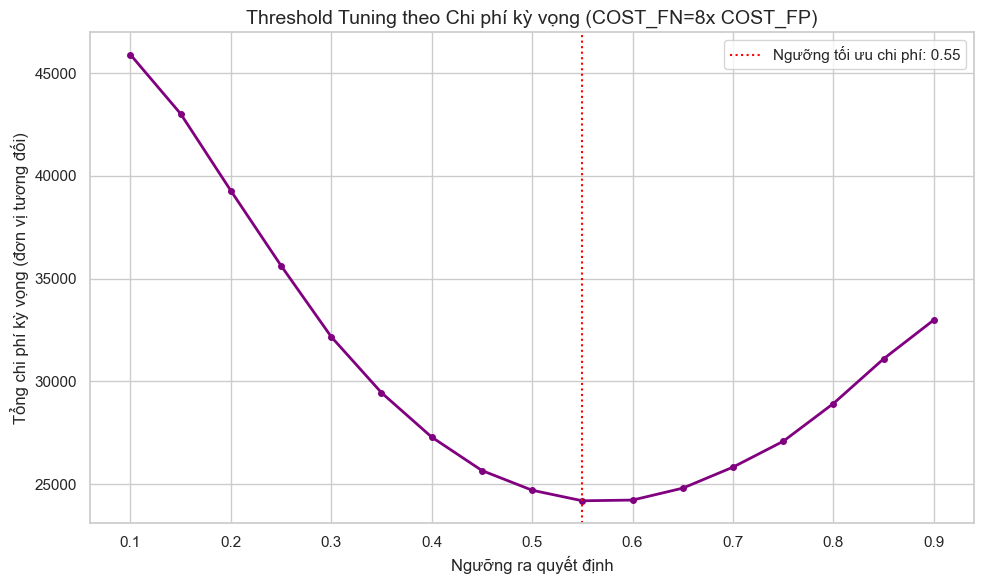

Ngưỡng tối ưu theo F1:          0.65
Ngưỡng tối ưu theo Chi phí:     0.55
=> Ngưỡng cost-based thường thấp hơn F1-based vì ưu tiên bắt được nhiều khách xấu hơn (đánh đổi bằng việc từ chối oan nhiều khách tốt hơn).


In [20]:
## Cải tiến 3b: Threshold theo Chi phí kỳ vọng (Cost-based)

## F1-Score coi trọng Precision và Recall như nhau, nhưng trong bài toán tín dụng, **để lọt 1 khách hàng xấu (False Negative)** thường tốn kém hơn nhiều so với **từ chối oan 1 khách hàng tốt (False Positive)** — vì FN có thể dẫn đến mất trắng cả khoản vay, còn FP chỉ là chi phí cơ hội.

## Giả định ở đây: 1 FN tốn kém gấp 8 lần 1 FP (con số này nên được thay bằng dữ liệu thực tế từ bộ phận rủi ro nếu có).

COST_FN = 8   # chi phí khi bỏ lọt 1 khách xấu (khoản vay có nguy cơ mất trắng)
COST_FP = 1   # chi phí cơ hội khi từ chối oan 1 khách tốt

costs = []
for thresh in thresholds:
    y_pred_custom = (y_val_prob >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_pred_custom)
    fp, fn = cm[0][1], cm[1][0]
    total_cost = fp * COST_FP + fn * COST_FN
    costs.append(total_cost)

best_cost_idx = np.argmin(costs)
best_cost_thresh = thresholds[best_cost_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, costs, color='purple', linewidth=2, marker='o', markersize=4)
plt.axvline(x=best_cost_thresh, color='red', linestyle=':', label=f'Ngưỡng tối ưu chi phí: {best_cost_thresh:.2f}')
plt.title(f'Threshold Tuning theo Chi phí kỳ vọng (COST_FN={COST_FN}x COST_FP)', fontsize=14)
plt.xlabel('Ngưỡng ra quyết định')
plt.ylabel('Tổng chi phí kỳ vọng (đơn vị tương đối)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Ngưỡng tối ưu theo F1:          {best_thresh:.2f}")
print(f"Ngưỡng tối ưu theo Chi phí:     {best_cost_thresh:.2f}")
print("=> Ngưỡng cost-based thường thấp hơn F1-based vì ưu tiên bắt được nhiều khách xấu hơn (đánh đổi bằng việc từ chối oan nhiều khách tốt hơn).")

In [21]:
y_test_prob = lgbm_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_prob)
print(f"AUC trên Test set (hoàn toàn độc lập): {test_auc:.4f}")

for label, thresh in [("F1-optimal", best_thresh), ("Cost-optimal", best_cost_thresh)]:
    y_pred_final = (y_test_prob >= thresh).astype(int)
    print(f"\n{'='*60}")
    print(f"BÁO CÁO PHÂN LOẠI TRÊN TEST SET (Ngưỡng {label}: {thresh:.2f})")
    print(classification_report(y_test, y_pred_final))
    cm = confusion_matrix(y_test, y_pred_final)
    print("MA TRẬN NHẦM LẪN (Confusion Matrix):")
    print(f"  Số người TỐT được duyệt vay đúng (TN): {cm[0][0]}")
    print(f"  Số người TỐT bị từ chối oan (FP):      {cm[0][1]}")
    print(f"  Số người XẤU bị lọt lưới (FN):         {cm[1][0]}")
    print(f"  Số người XẤU bị từ chối đúng (TP):     {cm[1][1]}")

AUC trên Test set (hoàn toàn độc lập): 0.7657

BÁO CÁO PHÂN LOẠI TRÊN TEST SET (Ngưỡng F1-optimal: 0.65)
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     42403
           1       0.24      0.45      0.32      3724

    accuracy                           0.84     46127
   macro avg       0.60      0.66      0.61     46127
weighted avg       0.89      0.84      0.86     46127

MA TRẬN NHẦM LẪN (Confusion Matrix):
  Số người TỐT được duyệt vay đúng (TN): 37221
  Số người TỐT bị từ chối oan (FP):      5182
  Số người XẤU bị lọt lưới (FN):         2051
  Số người XẤU bị từ chối đúng (TP):     1673

BÁO CÁO PHÂN LOẠI TRÊN TEST SET (Ngưỡng Cost-optimal: 0.55)
              precision    recall  f1-score   support

           0       0.96      0.77      0.86     42403
           1       0.19      0.62      0.29      3724

    accuracy                           0.76     46127
   macro avg       0.58      0.70      0.58     46127
weighted avg 

### Sensitivity Analysis: Threshold tối ưu thay đổi theo tỷ lệ Cost giả định

Vì không có số liệu chi phí thật từ đội rủi ro, ta không nên chỉ chốt 1 tỷ lệ (8x) rồi coi là chân lý. Biểu đồ dưới đây khảo sát threshold tối ưu ứng với nhiều tỷ lệ `COST_FN / COST_FP` khác nhau (3x, 5x, 8x, 12x, 15x), giúp thấy rõ: giả định kinh doanh thay đổi thì ngưỡng ra quyết định thay đổi theo hướng nào và mức độ bao nhiêu — đây là cách trình bày thuyết phục khi chưa chốt được số cost chính xác.

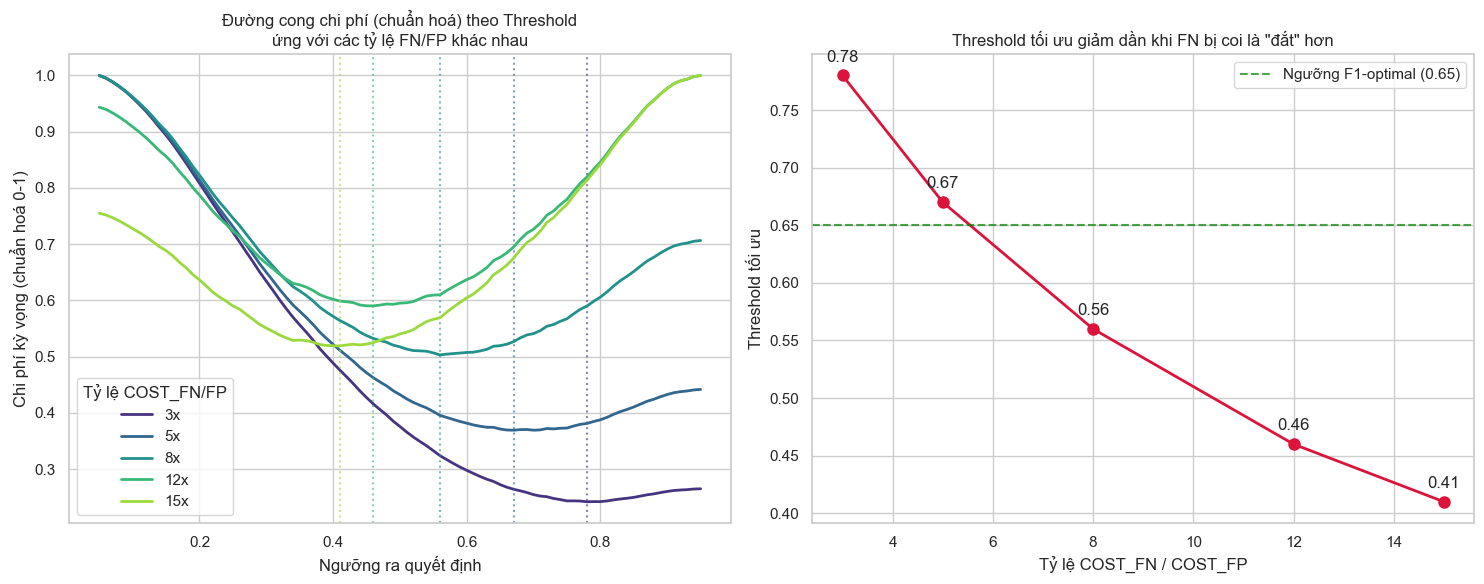

Bảng threshold tối ưu theo từng tỷ lệ cost giả định:
 cost_ratio  best_threshold
          3            0.78
          5            0.67
          8            0.56
         12            0.46
         15            0.41

=> Tỷ lệ cost càng cao (FN càng đắt) thì threshold tối ưu càng thấp,
   vì model phải hạ ngưỡng để 'bắt' được nhiều khách xấu hơn, chấp nhận từ chối oan nhiều khách tốt hơn.


In [22]:
# Sensitivity Analysis: threshold tối ưu theo nhiều tỷ lệ cost khác nhau (trên Validation)
cost_ratios = [3, 5, 8, 12, 15]
fine_thresholds = np.arange(0.05, 0.96, 0.01)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(cost_ratios)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sensitivity_results = []
for ratio, color in zip(cost_ratios, colors):
    costs_r = []
    for thresh in fine_thresholds:
        y_pred_r = (y_val_prob >= thresh).astype(int)
        cm = confusion_matrix(y_val, y_pred_r)
        fp, fn = cm[0][1], cm[1][0]
        costs_r.append(fp * 1 + fn * ratio)

    best_idx_r = np.argmin(costs_r)
    best_thresh_r = fine_thresholds[best_idx_r]
    sensitivity_results.append({'cost_ratio': ratio, 'best_threshold': best_thresh_r})

    # subplot trái: đường cong chi phí cho từng tỷ lệ
    axes[0].plot(fine_thresholds, costs_r / np.max(costs_r), color=color,
                 linewidth=2, label=f'{ratio}x')
    axes[0].axvline(x=best_thresh_r, color=color, linestyle=':', alpha=0.6)

axes[0].set_title('Đường cong chi phí (chuẩn hoá) theo Threshold\nứng với các tỷ lệ FN/FP khác nhau', fontsize=12)
axes[0].set_xlabel('Ngưỡng ra quyết định')
axes[0].set_ylabel('Chi phí kỳ vọng (chuẩn hoá 0-1)')
axes[0].legend(title='Tỷ lệ COST_FN/FP')
axes[0].grid(True)

# subplot phải: threshold tối ưu tăng/giảm theo tỷ lệ cost
sens_df = pd.DataFrame(sensitivity_results)
axes[1].plot(sens_df['cost_ratio'], sens_df['best_threshold'],
             marker='o', markersize=8, color='crimson', linewidth=2)
for _, row in sens_df.iterrows():
    axes[1].annotate(f"{row['best_threshold']:.2f}",
                      (row['cost_ratio'], row['best_threshold']),
                      textcoords="offset points", xytext=(0, 10), ha='center')
axes[1].axhline(y=best_thresh, color='green', linestyle='--', alpha=0.7,
                 label=f'Ngưỡng F1-optimal ({best_thresh:.2f})')
axes[1].set_title('Threshold tối ưu giảm dần khi FN bị coi là "đắt" hơn', fontsize=12)
axes[1].set_xlabel('Tỷ lệ COST_FN / COST_FP')
axes[1].set_ylabel('Threshold tối ưu')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Bảng threshold tối ưu theo từng tỷ lệ cost giả định:")
print(sens_df.to_string(index=False))
print("\n=> Tỷ lệ cost càng cao (FN càng đắt) thì threshold tối ưu càng thấp,")
print("   vì model phải hạ ngưỡng để 'bắt' được nhiều khách xấu hơn, chấp nhận từ chối oan nhiều khách tốt hơn.")